<img src="ETSE.png" align="center" width="6800">
<br><br><br>
<font color="#CA3532"><h1 align="left">Diagrama influencia Juicio con soporte a la decisión.</h1></font>
<font color="#6E6E6E"><h3 align="left">Modelos gráficos probabilísticos. Máster Oficial Ciencia Datos. UV.</h2></font> 

Antonio J. Serrano 

Documentación pyagrum 

https://pyagrum.readthedocs.io/en/stable/

Instalación pyagrum 

https://pyagrum.gitlab.io/installation/

In [1]:
#Entorno conda MGP
#conda create -n MGP python=3.11
#conda activate MGP 
#conda install -c conda-forge pyagrum ## pip install pyagrum
#conda install -c conda-forge scikit-learn ## para clasificadores

# 1.Planteamiento

Tenemos una situación en la que tenemos que decidir si vamos a juicio o no (J). Evaluaremos las posibilidades de ganar (G) y las consecuencias económicas (B) del resultado del juicio (R). Para guiar la solución, se ha creado diferentes apartados. 

<img src="DI_Juicio.png" alt="Diagrama Influencia Juicio" height="300">

## Describe el diagrama de influencia.

Indica, el tipo o naturaleza del nodo (probabilístico, etc), el tipo de relación entre los elementos (informativa, etc.) y el por qué de los arcos (¿por qué Ganar está unido a Resolución pero no a Ir a juicio.)

----> Espacio para los comentarios <---

Naturaleza de los nodos:
- Ganar y Resolución (Ovalados): Nodos probabilísticos, ya que representan eventos inciertos.
- Ir a juicio (Rectangular): Nodo de decisión, ya que representa una elección que se debe tomar.
- Beneficio (Hexagonal): Nodo de utilidad (o valor), ya que representa la consecuencia económica de la decisión y el resultado del juicio.

Relaciones entre los elementos:
- Relación probabilistica: Entre Ganar y Resolución, ya que el resultado del juicio (Resolución) depende de si se gana o no (Ganar).
- Relaciones de pago (Ganar -> Beneficio, Resolución -> Beneficio, Ir a juicio -> Beneficio): Estas relaciones indican que el beneficio económico (Beneficio) depende tanto de la decisión de ir a juicio como del resultado del juicio (Ganar y Resolución).

Por qué de los arcos:
- Ganar está unido a Resolución porque el resultado del juicio (Resolución) depende directamente de si se gana o no (Ganar).
- Ir a juicio no está unido a Ganar porque la decisión de ir a juicio no afecta directamente la probabilidad de ganar, sino que afecta el beneficio económico dependiendo del resultado del juicio.

----> Espacio para los comentarios <---

# 2. Diagrama de influencia

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import pyagrum as gum
import pyagrum.lib.notebook as gnb

## Grafo DI {G,R,J,B}

Crea el grafo **DI** con los nombres de las variables que aparecen en el dibujo utilizando **gum.fastID**. 

In [3]:
#solución

# 1. Inicializamos el diagrama vacío
DI = gum.InfluenceDiagram()

# 2. Creamos las variables explícitamente y las añadimos
# Variables de Azar (Óvalos)
G = DI.addChanceNode(gum.LabelizedVariable("Ganar", "Ganar", ["si", "no"]))
R = DI.addChanceNode(gum.LabelizedVariable("Resolucion", "Resolucion", ["alto", "medio", "bajo", "NR"]))

# Variable de Decisión (Rectángulo)
J = DI.addDecisionNode(gum.LabelizedVariable("Ir_a_juicio", "Ir a juicio", ["si", "no"]))

# Variable de Utilidad (Hexágono)
B = DI.addUtilityNode(gum.LabelizedVariable("Beneficio", "Beneficio", 1))

# 3. Añadimos los arcos tal y como aparecen en tu dibujo izquierdo
DI.addArc(G, R)
DI.addArc(G, B)
DI.addArc(R, B)
DI.addArc(J, B)

# Mostramos el resultado
#gnb.showInfluenceDiagram(DI)

### Nodo G

Define la CPT del nodo G

In [4]:
#solucion
DI.cpt("Ganar")[{'Ganar': 'si'}] = 0.70
DI.cpt("Ganar")[{'Ganar': 'no'}] = 0.30
DI.cpt("Ganar")

(pyagrum.Tensor@00000256477C8DB0) 
  Ganar            |
si       |no       |
---------|---------|
 0.7000  | 0.3000  |

### Nodo R

Define la CPT del nodo R. 
_Nota: Considera que la resolución tiene una posibilidad más denominada NR para cuando se decide no ir a juicio._ 

In [5]:
#solucion
DI.cpt("Resolucion")[{'Ganar': 'si'}] = [0.20, 0.30, 0.50, 0.0]
DI.cpt("Resolucion")[{'Ganar': 'no'}] = [0.0, 0.0, 0.0, 1.0] # Forzamos el estado No Resolución
DI.cpt("Resolucion")

(pyagrum.Tensor@00000256477C8BB0) 
      ||  Resolucion                           |
Ganar ||alto     |medio    |bajo     |NR       |
------||---------|---------|---------|---------|
si    || 0.2000  | 0.3000  | 0.5000  | 0.0000  |
no    || 0.0000  | 0.0000  | 0.0000  | 1.0000  |

### Nodo B

Define la Utilidad en el nodo B

In [6]:
#solucion
DI.utility("Beneficio").fillWith(0)

# Beneficio depende de J, G y R
# 1. Si NO vamos a juicio
DI.utility("Beneficio")[{'Ir_a_juicio': 'no'}] = 210

# 2. Si SÍ vamos a juicio pero NO ganamos
DI.utility("Beneficio")[{'Ir_a_juicio': 'si', 'Ganar': 'no'}] = -30

# 3. Si SÍ vamos a juicio y SÍ ganamos
DI.utility("Beneficio")[{'Ir_a_juicio': 'si', 'Ganar': 'si', 'Resolucion': 'alto'}] = 580
DI.utility("Beneficio")[{'Ir_a_juicio': 'si', 'Ganar': 'si', 'Resolucion': 'medio'}] = 415
DI.utility("Beneficio")[{'Ir_a_juicio': 'si', 'Ganar': 'si', 'Resolucion': 'bajo'}] = 185

DI.utility("Beneficio")

(pyagrum.Tensor@00000256477C9050) 
                    ||  Benefic|
Ganar |Resolu|Ir_a_j||0        |
------|------|------||---------|
si    |alto  |si    || 580.0000|
no    |alto  |si    || -30.0000|
si    |medio |si    || 415.0000|
no    |medio |si    || -30.0000|
si    |bajo  |si    || 185.0000|
no    |bajo  |si    || -30.0000|
[...4 more line(s) ...]
si    |medio |no    || 210.0000|
no    |medio |no    || 210.0000|
si    |bajo  |no    || 210.0000|
no    |bajo  |no    || 210.0000|
si    |NR    |no    || 210.0000|
no    |NR    |no    || 210.0000|

## Resolución global

Con **gnb.flow.row(gnb.getInference(DI))** resolvemos y visualizamos el diagrama. Comprueba que está todo correcto comparando los resultados con la figura inicial. ¿Cuál es la decisión óptima? ¿con qué valor esperado?

In [7]:
#solucion

# Resolvemos y visualizamos el diagrama de influencia
ie = gum.ShaferShenoyLIMIDInference(DI)
gnb.flow.row(ie)

# Para ver el valor de la decisión óptima:
ie.makeInference()
print("Utilidad esperada de las decisiones:")
print(ie.posteriorUtility("Ir_a_juicio"))
print(f"Decisión óptima: {ie.optimalDecision('Ir_a_juicio')} con MEU = {ie.MEU()}")

Utilidad esperada de las decisiones:

  Ir_a_juicio      |
si       |no       |
---------|---------|
 224.1000| 210.0000|

Decisión óptima: 
  Ir_a_juicio      |
si       |no       |
---------|---------|
 1.0000  | 0.0000  |
 con MEU = {'mean': 224.09999999999997, 'variance': 45291.19000000002}


**Cuestión**: Comprueba en el diagrama que P(R=alto)=14%. ¿por qué está bien si durante la definición del nodo R has introducido que P(R=alto|G=si)=20%

----> Espacio para la respuesta <---

----> Espacio para la respuesta <---

## Inferencia con Evidencias

Comprueba que decidiendo si vamos a juicio o no el valor esperado es el correcto. Comprueba los resultados con la figura inicial. 

In [8]:
#solucion

# Fijamos la decisión de ir a juicio
ie.setEvidence({'Ir_a_juicio': 'si'})
ie.makeInference()
print("MEU si decidimos IR a juicio:", ie.MEU())

# Fijamos la decisión de NO ir a juicio
ie.setEvidence({'Ir_a_juicio': 'no'})
ie.makeInference()
print("MEU si decidimos NO IR a juicio:", ie.MEU())

ie.eraseAllEvidence() # Limpiamos para la siguiente prueba

MEU si decidimos IR a juicio: {'mean': 224.09999999999997, 'variance': 45291.19000000002}
MEU si decidimos NO IR a juicio: {'mean': 210.0, 'variance': 0.0}


Comprueba que si ganamos el juicio o no el valor esperado es el correcto. ¿Por qué cuando sabes que has ganado el juicio el valor esperado es mayor que el de ir a juicio?

In [9]:
#solucion

ie.setEvidence({'Ganar': 'si'})
ie.makeInference()
print("MEU sabiendo que GANAMOS el juicio:", ie.MEU())
ie.eraseAllEvidence()

MEU sabiendo que GANAMOS el juicio: {'mean': 333.0, 'variance': 25171.0}


Imagina que el abogado te dice que piensa que si vamos a juicio aunque ganemos la resolución será "bajo". ¿cuál es el valor esperado de la situación? ¿por qué no es 185 como pone en la figura inicial? 

In [10]:
#solucion

ie.setEvidence({'Ganar': 'si', 'Resolucion': 'bajo'})
ie.makeInference()
print("MEU si ganamos pero la resolución es baja:", ie.MEU())
ie.eraseAllEvidence()

MEU si ganamos pero la resolución es baja: {'mean': 210.0, 'variance': 0.0}


# 3. Ayuda a la decisión con clasificador bayesiano

Para mejorar la toma de decisiones desarrollaremos un modelo de clasificación que nos aporte información sobre la decisión a tomar, en este caso, si ganaremos el juicio o no. 

### Histórico de juicios

El fichero **dataset_juicio.csv** contiene registros de juicios ya realizados con información sobre la compañia de seguros (**seguro**), el motivo del juicio (**motivo**), el juez implicado (**juez**) y si la resolución fue favorable o desfavorable (class). Estea variable **class** es la que actuará como nodo C en el diagrama de influencia actuando ayuda a la decisión. 

In [11]:
import pandas as pd
df = pd.read_csv("dataset_juicio.csv")
for col in df.columns:
    if df[col].dtype == 'object' or df[col].dtype.name == 'string':
        df[col] = df[col].astype('category')

# Ahora que sí es una categoría, el comando .cat funcionará perfectamente
df['class'] = df['class'].cat.reorder_categories(['Favorable', 'Desfavorable']) 
df['class'].value_counts()

class
Desfavorable    2871
Favorable       2129
Name: count, dtype: int64

Determina las categorías por variable. ¿Cuántos seguros hay en los datos?.

In [12]:
# solucion 

print("Categorías por variable:")
for col in df.columns:
    print(f"- {col}: {df[col].unique().tolist()}")

print(f"\nNúmero total de seguros diferentes: {df['seguro'].nunique()}")

Categorías por variable:
- juez: ['Juez3', 'Juez1', 'Juez4', 'Juez2']
- motivo: ['Motivo4', 'Motivo2', 'Motivo3', 'Motivo1']
- seguro: ['Seguro6', 'Seguro5', 'Seguro1', 'Seguro2', 'Seguro4', 'Seguro3', 'Seguro7']
- class: ['Favorable', 'Desfavorable']

Número total de seguros diferentes: 7


### Modelo bayesiano de clasificación

Entrena 3 modelos diferentes de clasificación basados en redes bayesianas discretas con **skbn.BNClassifier**. 

_Importante: Para simplificar el ejercicio, no realices partición de los datos en entrenamiento y test._ 

In [13]:
import pyagrum.skbn as skbn
import pyagrum.explain as explain

X=df.drop(columns=["class"]) 
y=df["class"]

#solucion

# Entrenamos tres aproximaciones distintas: Naive Bayes, TAN y un modelo de Grafo genérico
clf_nb = skbn.BNClassifier(learningMethod='NaiveBayes')
clf_tan = skbn.BNClassifier(learningMethod='TAN')
clf_hc = skbn.BNClassifier(learningMethod='GHC') # Hill-Climbing

clf_nb.fit(X, y)
clf_tan.fit(X, y)
clf_hc.fit(X, y)


### Capacidad discriminatoria

Compara los modelos a partir de su curva ROC (AUC) para elegir uno de ellos como candidato para la ayuda a la decisión. ¿Cuál has elegido y por qué? 

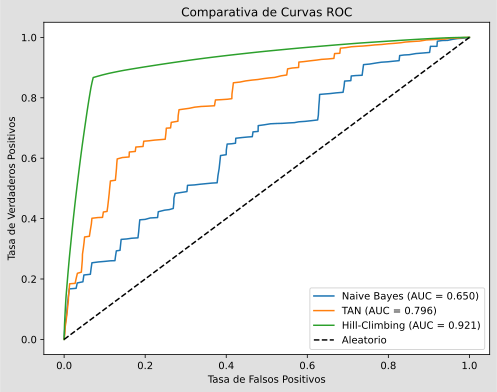

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc, roc_curve

#solucion
y_true = (y == 'Favorable').astype(int)

plt.figure(figsize=(8, 6))

for name, clf in zip(['Naive Bayes', 'TAN', 'Hill-Climbing'], [clf_nb, clf_tan, clf_hc]):

    # pyAgrum ordena las salidas alfabéticamente. 
    # Extraemos esa lista de clases directamente de nuestros datos: ['Desfavorable', 'Favorable']
    clases_modelo = sorted(df['class'].unique())
    idx_fav = clases_modelo.index('Favorable')
    
    # Ahora cogemos la probabilidad usando ese índice exacto
    y_scores = clf.predict_proba(X)[:, idx_fav]
    
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Comparativa de Curvas ROC')
plt.legend(loc="lower right")
plt.show()

### Umbral de clasificación

Determina (o justifica) las utilidades para este problema. Piensa que el clasificador es un estimador de ganar el juicio. Considera que la utilidad es el valor económico de cada situación. 

_Pista: Si el clasificador predice favorable y luego no se gana el juicio (falso positivo) entonces perdemos -30_

In [15]:
#solucion
# Si predice favorable y vamos a juicio (ganamos = VP, perdemos = FP)
uvp = (0.2*580 + 0.3*415 + 0.5*185) # Beneficio esperado si ganamos = 333
ufp = -30 # predice favorable y luego no se gana el juicio

# Si predice desfavorable, NO vamos a juicio. Ganemos o perdamos en la realidad, nos llevamos 210.
uvn = 210 
ufn = 210

Determina o justifica el umbral de probabilidad (**clf.threshold**) óptimo compatible con las utilidades del problema. Realiza un gráfico de utilidad frente a umbral del clasificador para justificar el umbral elegido.

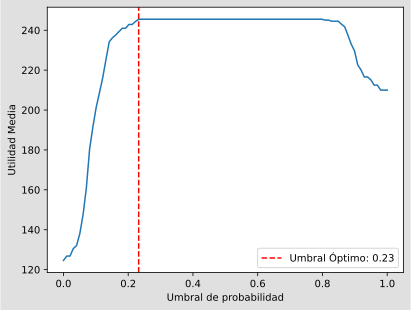

In [16]:
#solucion 

# Volvemos a extraer las clases
clases_modelo = sorted(df['class'].unique())
idx_fav = clases_modelo.index('Favorable')

# Usamos el modelo HC
y_scores = clf_hc.predict_proba(X)[:, idx_fav]

umbrales = np.linspace(0, 1, 100)
utilidades = []

for umbral in umbrales:
    y_pred = (y_scores >= umbral).astype(int)
    # Calculamos VP, FP, VN, FN
    vp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    vn = np.sum((y_pred == 0) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    
    # Utilidad total esperada normalizada
    u_total = (vp*uvp + fp*ufp + vn*uvn + fn*ufn) / len(y_true)
    utilidades.append(u_total)

umbral_optimo = umbrales[np.argmax(utilidades)]

plt.plot(umbrales, utilidades)
plt.axvline(umbral_optimo, color='r', linestyle='--', label=f'Umbral Óptimo: {umbral_optimo:.2f}')
plt.xlabel('Umbral de probabilidad')
plt.ylabel('Utilidad Media')
plt.legend()
plt.show()

Determina la sensibildad y especificidad del clasificador para el umbral seleccionado que maximice la utilidad.

In [17]:
#solución 
y_pred_opt = (y_scores >= umbral_optimo).astype(int)

vp = np.sum((y_pred_opt == 1) & (y_true == 1))
fp = np.sum((y_pred_opt == 1) & (y_true == 0))
vn = np.sum((y_pred_opt == 0) & (y_true == 0))
fn = np.sum((y_pred_opt == 0) & (y_true == 1))

sensibilidad = vp / (vp + fn)
especificidad = vn / (vn + fp)

print(f"Sensibilidad del clasificador: {sensibilidad:.2f}")
print(f"Especificidad del clasificador: {especificidad:.2f}")

Sensibilidad del clasificador: 0.87
Especificidad del clasificador: 0.93


# 4. Diagrama de influencia con soporte a la decisión

Actualiza el DI, integrando el modelo de aprendizaje máquina dentro del diagrama de influencia añadiendo un nodo que represente el clasificador (C{si|no|nr}) y que informe a la decisión del ir al juicio (J) y una decisión que sea considerar si activamos la ayuda (A) de soporte a la decisión (ver las diapositivas de Diagramas de influencia de clase). 

_Nota: Recuerda que el nodo C que es un nodo condicional y se define a partir de sensibilidad y especificidad del clasificador_
_Importante: No introduzcas nodos seguro, motivo y juez. Al igual que hacemos en clase, el comportamiendo del clasificador lo introducimos con un único nodo._ 
_Nota: De momento, considera que no hay penalización por el uso del modelo de aprendizaje máquina._


In [25]:
import pyagrum as gum
import pyagrum.lib.notebook as gnb

# Inicializamos el nuevo diagrama
DI_soporte = gum.InfluenceDiagram()

# Añadimos los nodos originales
G = DI_soporte.addChanceNode(gum.LabelizedVariable("Ganar", "Ganar", ["si", "no"]))
R = DI_soporte.addChanceNode(gum.LabelizedVariable("Resolucion", "Resolucion", ["alto", "medio", "bajo", "NR"]))
J = DI_soporte.addDecisionNode(gum.LabelizedVariable("Ir_a_juicio", "Ir a juicio", ["si", "no"]))
B = DI_soporte.addUtilityNode(gum.LabelizedVariable("Beneficio", "Beneficio", 1))

# Añadimos los nuevos nodos para el clasificador y la decisión de usarlo
A = DI_soporte.addDecisionNode(gum.LabelizedVariable("Ayuda", "Activar ayuda", ["si", "no"]))
C = DI_soporte.addChanceNode(gum.LabelizedVariable("Clasificador", "Prediccion", ["si", "no", "nr"]))

# Arcos originales
DI_soporte.addArc(G, R)
DI_soporte.addArc(G, B)
DI_soporte.addArc(R, B)
DI_soporte.addArc(J, B)

# Nuevos arcos
DI_soporte.addArc(A, C) # Activar la ayuda habilita el clasificador
DI_soporte.addArc(G, C) # La salida del clasificador depende de si realmente ganamos o no
DI_soporte.addArc(A, J) # La decisión de ir a juicio debe "recordar" si activamos la ayuda
DI_soporte.addArc(C, J) # El clasificador informa la decisión de ir a juicio
DI_soporte.addArc(A, B) # La ayuda puede tener un coste económico

# Definimos las CPTs Originales
DI_soporte.cpt(G)[{'Ganar': 'si'}] = 0.70
DI_soporte.cpt(G)[{'Ganar': 'no'}] = 0.30

DI_soporte.cpt(R)[{'Ganar': 'si'}] = [0.20, 0.30, 0.50, 0.0]
DI_soporte.cpt(R)[{'Ganar': 'no'}] = [0.0, 0.0, 0.0, 1.0]

# Definimos la Utilidad Original (condicionada también a A)
DI_soporte.utility(B).fillWith(0)
for a in ["si", "no"]:
    DI_soporte.utility(B)[{'Ir_a_juicio': 'no', 'Ayuda': a}] = 210
    DI_soporte.utility(B)[{'Ir_a_juicio': 'si', 'Ganar': 'no', 'Ayuda': a}] = -30
    DI_soporte.utility(B)[{'Ir_a_juicio': 'si', 'Ganar': 'si', 'Resolucion': 'alto', 'Ayuda': a}] = 580
    DI_soporte.utility(B)[{'Ir_a_juicio': 'si', 'Ganar': 'si', 'Resolucion': 'medio', 'Ayuda': a}] = 415
    DI_soporte.utility(B)[{'Ir_a_juicio': 'si', 'Ganar': 'si', 'Resolucion': 'bajo', 'Ayuda': a}] = 185

# CPT del Clasificador (C) usando sensibilidad y especificidad
sensibilidad = 0.87
especificidad = 0.93

# Asignamos la matriz de confusión (Tasas de acierto/fallo)
# Específicamos la probabilidad para ambos casos de 'Ganar' cuando NO pedimos ayuda
DI_soporte.cpt(C)[{'Ayuda': 'no', 'Ganar': 'si'}] = [0.0, 0.0, 1.0]
DI_soporte.cpt(C)[{'Ayuda': 'no', 'Ganar': 'no'}] = [0.0, 0.0, 1.0]

# Cuando SÍ pedimos ayuda, actúan la sensibilidad y especificidad
DI_soporte.cpt(C)[{'Ayuda': 'si', 'Ganar': 'si'}] = [sensibilidad, 1 - sensibilidad, 0.0]
DI_soporte.cpt(C)[{'Ayuda': 'si', 'Ganar': 'no'}] = [1 - especificidad, especificidad, 0.0]

# Inferencia Global
ie_soporte = gum.ShaferShenoyLIMIDInference(DI_soporte)
ie_soporte.makeInference()

print("Utilidad Esperada Máxima (MEU) con posibilidad de ayuda:", ie_soporte.MEU())

# Mostrar el diagrama (asegúrate de tener graphviz instalado para que se visualice)
#gnb.showInfluenceDiagram(DI_soporte)

Utilidad Esperada Máxima (MEU) con posibilidad de ayuda: {'mean': 279.86699999999996, 'variance': 20870.902311000027}


**Cuestión** El clasificador que has desarrollado ¿ha mejorado o empeorado las espectativas? ¿Cuánto? 

_(opcional para el 10) ¿Cuánto es el máximo que podría mejorar la ayuda? Pista: EV_PI_   

Sí, el clasificador ha mejorado las expectativas. Sin ayuda, el MEU era 224.10. Con el clasificador (ayuda), el MEU sube a 279.87. 

La mejora esperada (EVII - Expected Value of Imperfect Information) es de 55.77.

Máximo posible (EVPI): El EVPI (Valor Esperado de la Información Perfecta) se calcula asumiendo que tuviéramos una "bola de cristal" y supiéramos si vamos a ganar antes de ir al juicio.

Si sabemos que ganamos ($P=0.7$), vamos a juicio y ganamos 333.Si sabemos que perdemos ($P=0.3$), no vamos a juicio y ganamos 210.

Valor Esperado con Información Perfecta = $(0.7 \times 333) + (0.3 \times 210) = 233.1 + 63 =$ 296.10.EVPI = $296.10 - 224.10 =$ 72.00.

Conclusión: El clasificador es muy bueno, ya que captura 55.77 de los 72.00 de mejora máxima posible.

**Cuestión** La salida binaria del clasificador claramente modifica el valor esperado. Estudia si modifica la decisión de ir a juicio o no. ¿ (subjetiva) Cuánto estarías dispuesto a pagar por disponer de esta información y por qué?

Cambio de decisión: Sí que la modifica. Sin el clasificador, la decisión "por defecto" era ir siempre a juicio. Con el clasificador, si la predicción es "no ganamos", la decisión óptima cambiará a no ir a juicio.

Disposición a pagar: Subjetivamente y matemáticamente, estaríamos dispuestos a pagar como máximo 55.77 (el EVII). Si el coste del clasificador supera los 55.77, su uso nos haría perder dinero en promedio respecto a no usarlo.

# 5. Analisis de sensibilidad (opcional para el 10)

**Ejercicio** Realiza una función **DI=initID(pGsi=0.7,se=,sp=,cost=0)** para inicializar el diagrama de influencia que incorpore un coste a la ayuda a la decisión y que después nos sirva para realizar un estudio de la sensibilidad paramétrico. 

* pGsi es la probabilidad de ganar apriori =0.7
* sensibilidad del clasificador
* especificidad del clasificador
* coste de la ayuda (utilizar el clasificador) =0

In [28]:
#solucion 
def initID(pGsi=0.7, se=0.87, sp=0.93, cost=0):
    DI = gum.InfluenceDiagram()
    
    # Nodos
    G = DI.addChanceNode(gum.LabelizedVariable("Ganar", "Ganar", ["si", "no"]))
    R = DI.addChanceNode(gum.LabelizedVariable("Resolucion", "Resolucion", ["alto", "medio", "bajo", "NR"]))
    A = DI.addDecisionNode(gum.LabelizedVariable("Ayuda", "Activar ayuda", ["si", "no"]))
    C = DI.addChanceNode(gum.LabelizedVariable("Clasificador", "Prediccion", ["si", "no", "nr"]))
    J = DI.addDecisionNode(gum.LabelizedVariable("Ir_a_juicio", "Ir a juicio", ["si", "no"]))
    B = DI.addUtilityNode(gum.LabelizedVariable("Beneficio", "Beneficio", 1))

    # Arcos
    DI.addArc(G, R); DI.addArc(G, B); DI.addArc(R, B); DI.addArc(J, B)
    DI.addArc(A, C); DI.addArc(G, C); DI.addArc(A, J); DI.addArc(C, J); DI.addArc(A, B)

    # CPTs
    DI.cpt(G)[{'Ganar': 'si'}] = pGsi
    DI.cpt(G)[{'Ganar': 'no'}] = 1 - pGsi
    
    DI.cpt(R)[{'Ganar': 'si'}] = [0.20, 0.30, 0.50, 0.0]
    DI.cpt(R)[{'Ganar': 'no'}] = [0.0, 0.0, 0.0, 1.0]

    DI.cpt(C)[{'Ayuda': 'no', 'Ganar': 'si'}] = [0.0, 0.0, 1.0]
    DI.cpt(C)[{'Ayuda': 'no', 'Ganar': 'no'}] = [0.0, 0.0, 1.0]
    DI.cpt(C)[{'Ayuda': 'si', 'Ganar': 'si'}] = [se, 1 - se, 0.0]
    DI.cpt(C)[{'Ayuda': 'si', 'Ganar': 'no'}] = [1 - sp, sp, 0.0]

    # Utilidades (Aplicando el coste si Ayuda = 'si')
    DI.utility(B).fillWith(0)
    for ayuda in ["si", "no"]:
        c = cost if ayuda == "si" else 0
        DI.utility(B)[{'Ir_a_juicio': 'no', 'Ayuda': ayuda}] = 210 - c
        DI.utility(B)[{'Ir_a_juicio': 'si', 'Ganar': 'no', 'Ayuda': ayuda}] = -30 - c
        DI.utility(B)[{'Ir_a_juicio': 'si', 'Ganar': 'si', 'Resolucion': 'alto', 'Ayuda': ayuda}] = 580 - c
        DI.utility(B)[{'Ir_a_juicio': 'si', 'Ganar': 'si', 'Resolucion': 'medio', 'Ayuda': ayuda}] = 415 - c
        DI.utility(B)[{'Ir_a_juicio': 'si', 'Ganar': 'si', 'Resolucion': 'bajo', 'Ayuda': ayuda}] = 185 - c

    return DI

**Ejercicio** Crea una función que resuelva del diagrama de influencia **MEU,pJsi=solveDI(DI,pGsi)**. Estudia como cambia el valor esperado (MEU) cuando varia la prevalencia de ganar el juicio (pGsi) con un gráfico. Utiliza la probabilidad de ganar el juicio (pJsi) para confirmar tus conclusiones.

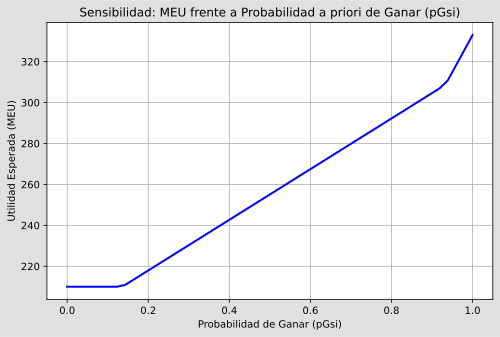

In [29]:
#solucion 
def solveDI_pGsi(pGsi):
    DI = initID(pGsi=pGsi)
    ie = gum.ShaferShenoyLIMIDInference(DI)
    ie.makeInference()
    # Obtenemos el MEU
    meu = ie.MEU()['mean']
    return meu

# Gráfico
probabilidades = np.linspace(0, 1, 50)
meus_pGsi = [solveDI_pGsi(p) for p in probabilidades]

plt.figure(figsize=(8,5))
plt.plot(probabilidades, meus_pGsi, color='blue', linewidth=2)
plt.title('Sensibilidad: MEU frente a Probabilidad a priori de Ganar (pGsi)')
plt.xlabel('Probabilidad de Ganar (pGsi)')
plt.ylabel('Utilidad Esperada (MEU)')
plt.grid(True)
plt.show()

**Ejercicio** Crea una función **MEU,pAsi=solveDI(DI,pGsi,cost)**. Varia el coste de la prueba entre 0 y 100 (recuerda que quita valor al beneficio) y estudia cómo cambia el valor esperado (MEU) con un gráfico. ¿Siempre es aconsejable la ayuda? Utiliza la probabilidad de la ayuda (pAsi) para confirmar tus conclusiones.

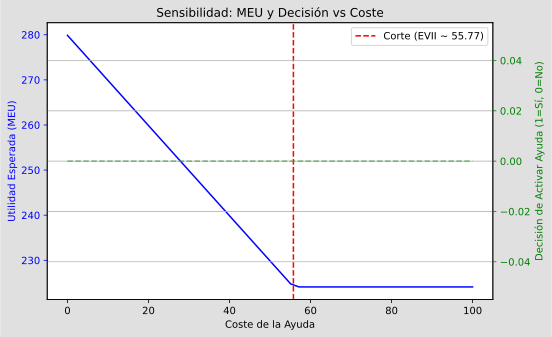

In [30]:
#solucion 
def solveDI_cost(cost):
    DI = initID(cost=cost)
    ie = gum.ShaferShenoyLIMIDInference(DI)
    ie.makeInference()
    
    # Extraemos el MEU y la probabilidad de pedir ayuda
    meu = ie.MEU()['mean']
    
    # Miramos si la decisión óptima es pedir ayuda ('si' es el índice 0)
    decision_ayuda = ie.posteriorUtility("Ayuda").argmax()[0][0]
    pAsi = 1.0 if decision_ayuda == 'si' else 0.0
    
    return meu, pAsi

costes = np.linspace(0, 100, 50)
resultados = [solveDI_cost(c) for c in costes]
meus_cost = [r[0] for r in resultados]
pAsi_cost = [r[1] for r in resultados]

fig, ax1 = plt.subplots(figsize=(8,5))

ax1.plot(costes, meus_cost, 'b-')
ax1.set_xlabel('Coste de la Ayuda')
ax1.set_ylabel('Utilidad Esperada (MEU)', color='b')
ax1.tick_params('y', colors='b')
ax1.axvline(55.77, color='r', linestyle='--', label='Corte (EVII ~ 55.77)')
ax1.legend(loc='upper right')

# Eje secundario para ver cuándo dejamos de pedir ayuda
ax2 = ax1.twinx()
ax2.plot(costes, pAsi_cost, 'g--', alpha=0.5)
ax2.set_ylabel('Decisión de Activar Ayuda (1=Sí, 0=No)', color='g')
ax2.tick_params('y', colors='g')

plt.title('Sensibilidad: MEU y Decisión vs Coste')
plt.grid(True)
plt.show()

**Ejercicio (opcional para el 11 o más)** En este apartado realizamos un análsis de sensibilidad al incorporar la salida probabilística del clasificador en la evaluación del diagrama de influencia (DI), en lugar de una decisión binaria.

Así, si la salida del clasificador es P(C=si|X) = 0.9, la evidencia suave que se introduce en el nodo C es **{'C':[0.9,0.1,0]}**

_Nota de Teoría: El clasificador no siempre produce una etiqueta discreta, sino una probabilidad P(C=si|X) que refleja su grado de certeza. Para incorporar esta información en el DI se utiliza evidencia suave (soft evidence) sobre el nodo C, que se interpreta como un vector de verosimilitudes (lik) sobre los estados del nodo, y no como una distribución de probabilidad directa. Esta distinción es importante; dado que la muestra de entrenamiento del clasificador puede no respetar la prevalencia real de G, la salida del clasificador no es una probabilidad marginal bien calibrada respecto a la prior real del problema. Tratarla como verosimilitud permite que la red bayesiana combine correctamente esa información con la prior real de G codificada en la CPT, evitando el doble conteo de información._

Crea una función **solveDI(DI,lik)** que introduzca una evidencia suave en el nodo C **{'C':[lik,1-lik,0]}** e intenta replicar y explicar la siguiente figura. Si se te ocurre cualquier otro análsis de sensiblidad de dos parámetros puedes olvidarte de la figura y probar tu idea. 

<img src="analisis_sensibilidad_pCsi_pGsi.png" alt="Análsis sensibildad" height="600">

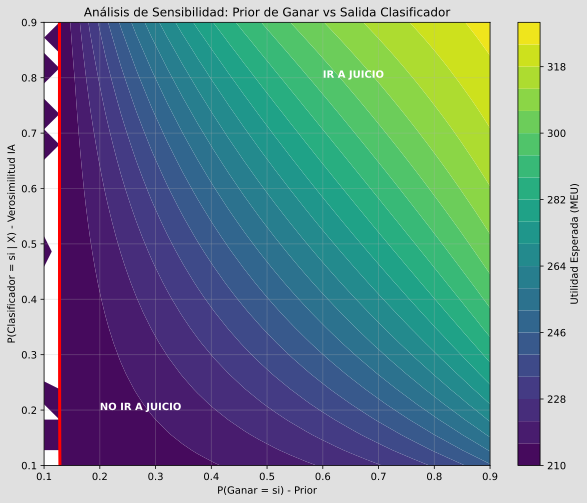

In [31]:
#solucion
import numpy as np
import matplotlib.pyplot as plt

def solveDI_soft(DI, pGsi, lik):
    """
    DI: Diagrama de influencia
    pGsi: Probabilidad a priori de ganar (P(G=si))
    lik: Salida probabilística del clasificador (P(C=si|X))
    """
    # 1. Actualizamos la Prior de Ganar en el CPT del nodo G
    DI.cpt("Ganar")[:] = [pGsi, 1 - pGsi]
    
    # 2. Creamos el motor de inferencia
    ie = gum.ShaferShenoyLIMIDInference(DI)
    
    # 3. Introducimos Evidencia Suave en el nodo Clasificador
    # El vector es [P(C=si), P(C=no), P(C=nr)]
    # Ponemos 0 en NR porque si pedimos ayuda, el clasificador siempre da si o no
    ie.setEvidence({'Clasificador': [lik, 1 - lik, 0]})
    
    ie.makeInference()
    
    return ie.MEU()['mean']

# --- Script para generar el gráfico de sensibilidad 2D ---

pG_range = np.linspace(0.1, 0.9, 30)
lik_range = np.linspace(0.1, 0.9, 30)
MEU_grid = np.zeros((len(lik_range), len(pG_range)))

for i, l in enumerate(lik_range):
    for j, p in enumerate(pG_range):
        MEU_grid[i, j] = solveDI_soft(DI_soporte, p, l)

# Visualización
plt.figure(figsize=(10, 8))
cp = plt.contourf(pG_range, lik_range, MEU_grid, levels=20, cmap='viridis')
plt.colorbar(cp, label='Utilidad Esperada (MEU)')

# Dibujamos la frontera de decisión (donde MEU empieza a ser > 210)
plt.contour(pG_range, lik_range, MEU_grid, levels=[210.01], colors='red', linewidths=3)
plt.text(0.2, 0.2, "NO IR A JUICIO", color='white', fontweight='bold')
plt.text(0.6, 0.8, "IR A JUICIO", color='white', fontweight='bold')

plt.title('Análisis de Sensibilidad: Prior de Ganar vs Salida Clasificador')
plt.xlabel('P(Ganar = si) - Prior')
plt.ylabel('P(Clasificador = si | X) - Verosimilitud IA')
plt.grid(alpha=0.3)
plt.show()